In [1]:
import os

current_dir = os.getcwd()
print(current_dir)
os.chdir("..")
print(os.getcwd())



/Users/giangluong/Desktop/MasterDS/Thesis/LuongThiGiang_Thesis_Code/notebooks
/Users/giangluong/Desktop/MasterDS/Thesis/LuongThiGiang_Thesis_Code


In [2]:
import ccxt
import pandas as pd
import yaml
from pathlib import Path
from datetime import datetime, timezone
from loguru import logger
import time

def load_yaml(path: str):
    with open(path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)

def ensure_dir(path: Path):
    path.mkdir(parents=True, exist_ok=True)

def fetch_ohlcv(
    exchange,
    symbol: str,
    start_date: str,
    end_date: str,
    interval: str = "1d",
    limit: int = 1000
) -> pd.DataFrame:
    since = int(
        datetime.fromisoformat(start_date)
        .replace(tzinfo=timezone.utc)
        .timestamp()
        * 1000
    )
    end_ts = int(
        datetime.fromisoformat(end_date)
        .replace(tzinfo=timezone.utc)
        .timestamp()
        * 1000
    )

    all_data = []
    while since < end_ts:
        try:
            data = exchange.fetch_ohlcv(
                symbol,
                timeframe=interval,
                since=since,
                limit=limit,
            )
            if not data:
                break

            all_data += data
            since = data[-1][0] + 1  # next start
            time.sleep(exchange.rateLimit / 1000)
        except Exception as e:
            logger.warning(f"Error fetching {symbol} at {since}: {e}")
            time.sleep(3)
            continue

    if not all_data:
        return pd.DataFrame(
            columns=["timestamp", "open", "high", "low", "close", "volume"]
        )

    df = pd.DataFrame(
        all_data,
        columns=["timestamp", "open", "high", "low", "close", "volume"],
    )
    df = df[df["timestamp"] <= end_ts]
    df["datetime"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
    df = df.set_index("datetime").sort_index()
    df = df.drop_duplicates()

    return df


In [11]:
# Configs cho lần fetch 
CONFIG_PATH = "config/universe_top20.yaml"
INTERVAL = "1d"
START_DATE = "2020-01-01"
END_DATE = "2025-09-30"

# Đích lưu file 
OUTPUT_ROOT = Path("data/raw")

# === Load universe config ===
config = load_yaml(CONFIG_PATH)
symbols = config.get("symbols", [])

if not symbols:
    logger.error("Không tìm thấy cặp coin nào trong universe_top20.yaml")
else:
    ensure_dir(OUTPUT_ROOT)

    exchange = ccxt.binance(
        {
            "enableRateLimit": True,
            "options": {"adjustForTimeDifference": True},
        }
    )

    logger.info(
        f"Đang lấy dữ liệu OHLCV cho {len(symbols)}  "
        f"Từ ngày {START_DATE} đến ngày {END_DATE} ({INTERVAL})"
    )

    for symbol in symbols:
        safe_symbol = symbol.replace("/", "_")  # BTC/USDT -> BTC_USDT
        outfile = OUTPUT_ROOT / f"{safe_symbol}_{INTERVAL}.csv"

        if outfile.exists():
            logger.info(f"Bỏ qua {symbol} (đã tồn tại ở file {outfile})")
            continue

        try:
            df = fetch_ohlcv(
                exchange=exchange,
                symbol=symbol,
                start_date=START_DATE,
                end_date=END_DATE,
                interval=INTERVAL,
            )

            if df.empty:
                logger.warning(f"No data for {symbol}")
                continue

            df.to_csv(outfile)
            logger.success(f"Đã lưu {symbol}: {len(df)} dòng -> {outfile}")
        except Exception as e:
            logger.error(f"Lỗi không lấy được dữ liệu {symbol}: {e}")

    logger.info("Hoàn thành tải dữ liệu.")


2025-12-24 00:22:27.525 | INFO     | __main__:<module>:26 - Đang lấy dữ liệu OHLCV cho 21  Từ ngày 2020-01-01 đến ngày 2025-09-30 (1d)
2025-12-24 00:22:27.526 | INFO     | __main__:<module>:36 - Bỏ qua BTC/USDT (đã tồn tại ở file data/raw/BTC_USDT_1d.csv)
2025-12-24 00:22:27.526 | INFO     | __main__:<module>:36 - Bỏ qua BCH/USDT (đã tồn tại ở file data/raw/BCH_USDT_1d.csv)
2025-12-24 00:22:27.527 | INFO     | __main__:<module>:36 - Bỏ qua ETH/USDT (đã tồn tại ở file data/raw/ETH_USDT_1d.csv)
2025-12-24 00:22:27.527 | INFO     | __main__:<module>:36 - Bỏ qua SOL/USDT (đã tồn tại ở file data/raw/SOL_USDT_1d.csv)
2025-12-24 00:22:27.528 | INFO     | __main__:<module>:36 - Bỏ qua BNB/USDT (đã tồn tại ở file data/raw/BNB_USDT_1d.csv)
2025-12-24 00:22:27.528 | INFO     | __main__:<module>:36 - Bỏ qua XRP/USDT (đã tồn tại ở file data/raw/XRP_USDT_1d.csv)
2025-12-24 00:22:27.528 | INFO     | __main__:<module>:36 - Bỏ qua ADA/USDT (đã tồn tại ở file data/raw/ADA_USDT_1d.csv)
2025-12-24 00:22:2

In [12]:
import pandas as pd
import os

# Đọc dữ liệu EOS/USDT
eos_df = pd.read_csv('data/raw/EOS_USDT_1d.csv')
eos_df['datetime'] = pd.to_datetime(eos_df['datetime'])

# Đọc dữ liệu A/USDT
a_df = pd.read_csv('data/raw/A_USDT_1d.csv')
a_df['datetime'] = pd.to_datetime(a_df['datetime'])

# Tạo dòng cho ngày 27/5/2025 từ dữ liệu ngày 26/5/2025
date_27 = pd.to_datetime('2025-05-27 00:00:00+00:00')
if date_27 not in eos_df['datetime'].values:
    # Lấy dữ liệu ngày 26/5
    row_26 = eos_df[eos_df['datetime'] == pd.to_datetime('2025-05-26 00:00:00+00:00')].copy()
    if not row_26.empty:
        row_26['datetime'] = date_27
        # Thêm vào dataframe
        eos_df = pd.concat([eos_df, row_26], ignore_index=True)
        print("Đã thêm dữ liệu ngày 27/5/2025 (forward fill từ 26/5)")

# Thêm prefix cho các cột của A/USDT (trừ datetime)
a_df_renamed = a_df.copy()
for col in a_df_renamed.columns:
    if col != 'datetime':
        a_df_renamed.rename(columns={col: f'A_{col}'}, inplace=True)

# Merge dữ liệu theo datetime (outer join để giữ tất cả dữ liệu)
merged_df = pd.merge(eos_df, a_df_renamed, on='datetime', how='outer')

# Sắp xếp theo datetime
merged_df = merged_df.sort_values('datetime').reset_index(drop=True)

print("\nDữ liệu sau khi merge:")
print(merged_df[merged_df['datetime'] >= '2025-05-25'])
print("\n")

# Forward fill cho các giá trị missing
merged_df = merged_df.ffill()

print("Dữ liệu sau khi forward fill:")
print(merged_df[merged_df['datetime'] >= '2025-05-25'])
print("\n")

# Lưu kết quả vào file EOS_USDT_1d.csv
merged_df.to_csv('data/raw/EOS_USDT_1d.csv', index=False)
print(f"Đã lưu dữ liệu đã merge vào data/raw/EOS_USDT_1d.csv")

# Xóa file A_USDT_1d.csv
if os.path.exists('data/raw/A_USDT_1d.csv'):
    os.remove('data/raw/A_USDT_1d.csv')
    print("Đã xóa file data/raw/A_USDT_1d.csv")
else:
    print("File data/raw/A_USDT_1d.csv không tồn tại")

print("\nHoàn thành!")

Đã thêm dữ liệu ngày 27/5/2025 (forward fill từ 26/5)

Dữ liệu sau khi merge:
                      datetime     timestamp    open    high     low   close  \
1971 2025-05-25 00:00:00+00:00  1.748131e+12  0.7319  0.8155  0.7126  0.7660   
1972 2025-05-26 00:00:00+00:00  1.748218e+12  0.7660  0.7996  0.7530  0.7799   
1973 2025-05-27 00:00:00+00:00  1.748218e+12  0.7660  0.7996  0.7530  0.7799   
1974 2025-05-28 00:00:00+00:00           NaN     NaN     NaN     NaN     NaN   
1975 2025-05-29 00:00:00+00:00           NaN     NaN     NaN     NaN     NaN   
...                        ...           ...     ...     ...     ...     ...   
2095 2025-09-26 00:00:00+00:00           NaN     NaN     NaN     NaN     NaN   
2096 2025-09-27 00:00:00+00:00           NaN     NaN     NaN     NaN     NaN   
2097 2025-09-28 00:00:00+00:00           NaN     NaN     NaN     NaN     NaN   
2098 2025-09-29 00:00:00+00:00           NaN     NaN     NaN     NaN     NaN   
2099 2025-09-30 00:00:00+00:00           N

In [13]:
# aligned prices + log-returns
import numpy as np
from pathlib import Path

RAW_ROOT = Path("data/raw")
PROCESSED_ROOT = Path("data/processed")
INTERVAL = "1d"

ensure_dir(PROCESSED_ROOT)

# Load tất cả file raw theo interval
raw_files = sorted(RAW_ROOT.glob(f"*_{INTERVAL}.csv"))
if not raw_files:
    logger.error(f"No raw files found in {RAW_ROOT} with pattern '*_{INTERVAL}.csv'")
else:
    logger.info(f"Found {len(raw_files)} raw files in {RAW_ROOT}")

price_series = {}

for file in raw_files:
    symbol = file.stem.replace(f"_{INTERVAL}", "")

    df = pd.read_csv(file)
    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"], utc=True)
        df = df.set_index("datetime")
    elif "timestamp" in df.columns:
        df["datetime"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
        df = df.set_index("datetime")
    else:
        logger.warning(f"{file} has no 'datetime' or 'timestamp' column. Skipping.")
        continue

    df = df.sort_index()

    # Chỉ giữ giá đóng cửa để tính log-return
    if "close" not in df.columns:
        logger.warning(f"{file} has no 'close' column. Skipping.")
        continue

    close = df[["close"]].rename(columns={"close": symbol})

    # Resample theo ngày, forward-fill giá bị thiếu (sàn bảo trì, lỗi kỹ thuật)
    close_daily = close.resample("1D").ffill()

    price_series[symbol] = close_daily

if not price_series:
    logger.error("No valid price series were constructed.")
else:
    # Đồng bộ chuỗi thời gian: chỉ giữ những ngày cả 20 tài sản đều có dữ liệu
    close_aligned = pd.concat(price_series.values(), axis=1, join="inner")
    close_aligned.columns = list(price_series.keys())
    close_aligned = close_aligned.sort_index()

    # Tính log-returns: r_t = ln(P_t / P_{t-1})
    log_returns = np.log(close_aligned / close_aligned.shift(1))
    log_returns = log_returns.dropna(how="all")

    # Lưu ra data/processed
    close_outfile = PROCESSED_ROOT / f"close_prices_aligned_{INTERVAL}.csv"
    returns_outfile = PROCESSED_ROOT / f"log_returns_{INTERVAL}.csv"

    close_aligned.to_csv(close_outfile, index_label="date")
    log_returns.to_csv(returns_outfile, index_label="date")

    logger.success(f"Saved aligned close prices to {close_outfile}")
    logger.success(f"Saved log-returns to {returns_outfile}")


2025-12-24 00:24:00.191 | INFO     | __main__:<module>:16 - Found 20 raw files in data/raw
2025-12-24 00:24:00.442 | SUCCESS  | __main__:<module>:67 - Saved aligned close prices to data/processed/close_prices_aligned_1d.csv
2025-12-24 00:24:00.442 | SUCCESS  | __main__:<module>:68 - Saved log-returns to data/processed/log_returns_1d.csv


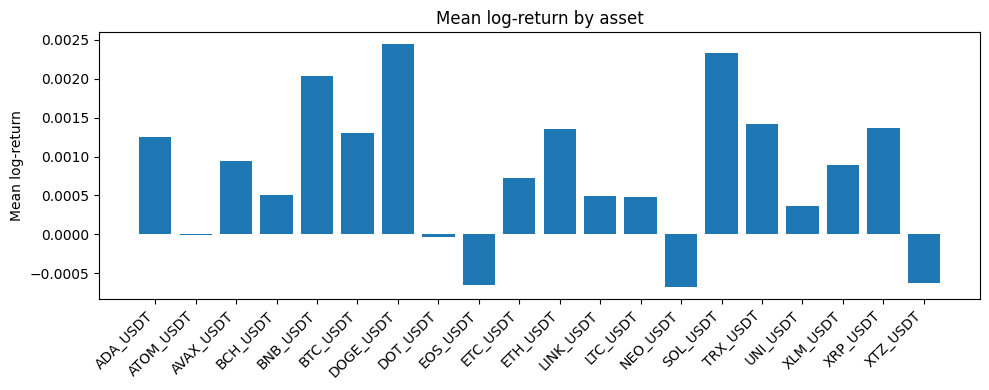

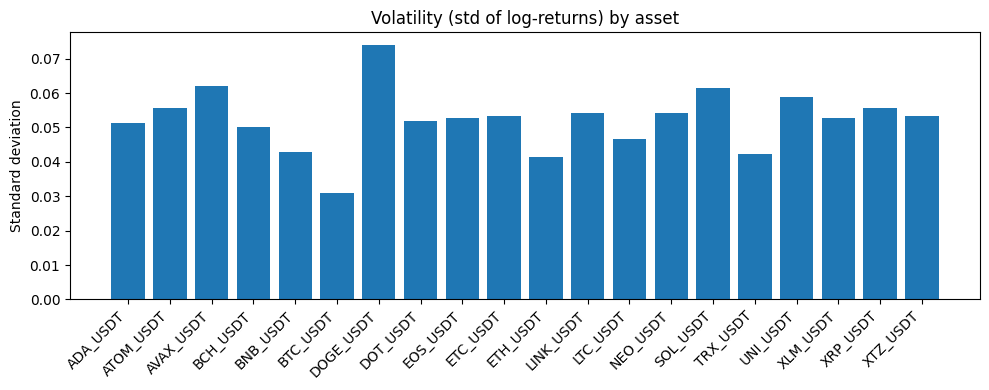

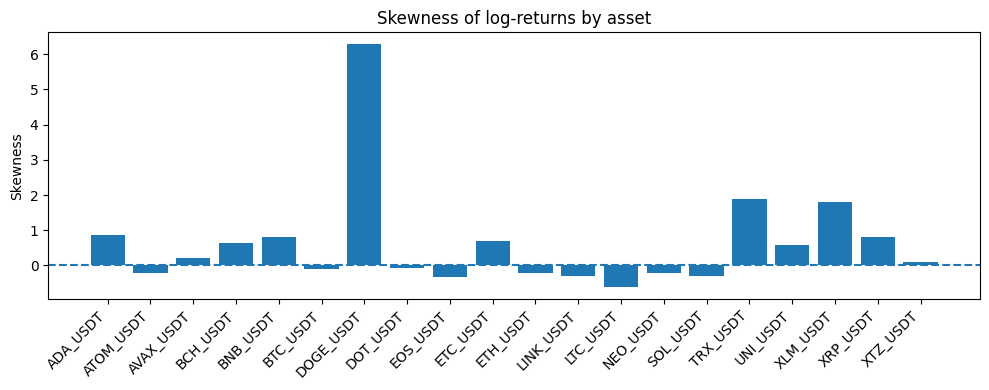

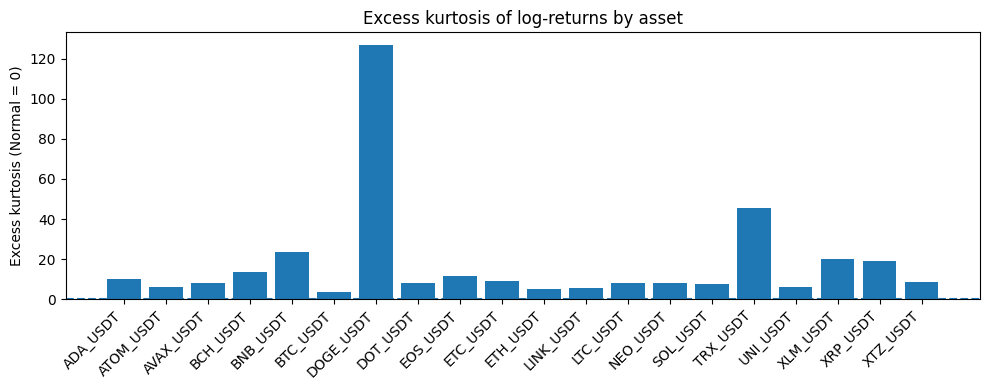

In [6]:

from pathlib import Path
import matplotlib.pyplot as plt

PROCESSED_ROOT = Path("data/processed")
INTERVAL = "1d"

returns_file = PROCESSED_ROOT / f"log_returns_{INTERVAL}.csv"
if "log_returns" not in globals():
    if not returns_file.exists():
        logger.error(f"{returns_file} not found. Run the processing cell first.")
    else:
        log_returns = pd.read_csv(returns_file, parse_dates=["date"])
        log_returns = log_returns.set_index("date")
        logger.info(f"Loaded log-returns from {returns_file}")

if "log_returns" in globals():
    # Tính 4 thống kê mô tả
    stats_df = pd.DataFrame({
        "mean_return": log_returns.mean(),
        "volatility": log_returns.std(),
        "skewness": log_returns.skew(),
        "excess_kurtosis": log_returns.kurtosis()
    })
    stats_df.index.name = "asset"

    # Sắp xếp tài sản theo alphabet 
    stats_df = stats_df.sort_index()

    # 1) Mean return
    plt.figure(figsize=(10, 4))
    plt.bar(stats_df.index, stats_df["mean_return"])
    plt.title("Mean log-return by asset")
    plt.ylabel("Mean log-return")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # 2) Volatility (standard deviation)
    plt.figure(figsize=(10, 4))
    plt.bar(stats_df.index, stats_df["volatility"])
    plt.title("Volatility (std of log-returns) by asset")
    plt.ylabel("Standard deviation")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # 3) Skewness
    plt.figure(figsize=(10, 4))
    plt.bar(stats_df.index, stats_df["skewness"])
    plt.title("Skewness of log-returns by asset")
    plt.ylabel("Skewness")
    plt.axhline(0, linestyle="--")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # 4) Excess kurtosis
    plt.figure(figsize=(10, 4))
    plt.bar(stats_df.index, stats_df["excess_kurtosis"])
    plt.title("Excess kurtosis of log-returns by asset")
    plt.ylabel("Excess kurtosis (Normal = 0)")
    plt.axhline(0, linestyle="--")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    stats_df


In [7]:
print(stats_df)

           mean_return  volatility  skewness  excess_kurtosis
asset                                                        
ADA_USDT      0.001251    0.051396  0.858018        10.202435
ATOM_USDT    -0.000014    0.055710 -0.208605         6.380521
AVAX_USDT     0.000943    0.062156  0.226257         8.131922
BCH_USDT      0.000510    0.050105  0.635839        13.697380
BNB_USDT      0.002037    0.042802  0.803394        23.412778
BTC_USDT      0.001299    0.031036 -0.089192         3.620298
DOGE_USDT     0.002442    0.073982  6.274262       126.736309
DOT_USDT     -0.000034    0.051926 -0.076588         8.040277
EOS_USDT     -0.000651    0.052631 -0.323696        11.541693
ETC_USDT      0.000718    0.053203  0.684425         8.985253
ETH_USDT      0.001357    0.041558 -0.207553         5.291689
LINK_USDT     0.000486    0.054184 -0.307536         5.488358
LTC_USDT      0.000478    0.046587 -0.617923         8.166514
NEO_USDT     -0.000683    0.054251 -0.204329         8.230277
SOL_USDT